### Линейная регрессия

In [1]:
# импорт нужных библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes  # подключаем датасет из sklearn
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn import metrics

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVR

In [2]:
# сразу напишем код функции, которая будет вычислять все нужные метрики

def Reg_Models_Evaluation_Metrics (model,X_train,y_train,X_test,y_test,y_pred):
    cv_score = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 10)

    # Calculating Adjusted R-squared
    r2 = model.score(X_test, y_test)
    # Number of observations is the shape along axis 0
    n = X_test.shape[0]
    # Number of features (predictors, p) is the shape along axis 1
    p = X_test.shape[1]
    # Adjusted R-squared formula
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    R2 = model.score(X_test, y_test)
    CV_R2 = cv_score.mean()

    print(f'RMSE:  {round(RMSE,4)}\n  R2: {round(R2,4)}\n Adjusted R2: {round(adjusted_r2, 4)}\n Cross Validated R2: {round(cv_score.mean(),4)}')
    return R2, adjusted_r2, CV_R2, RMSE

In [3]:
# Загрузка данных из Excel файла
df = pd.read_excel('Real estate valuation data set.xlsx')

# смотрим описание датасета
print(df.describe())

               No  X1 transaction date  X2 house age  \
count  414.000000           414.000000    414.000000   
mean   207.500000          2013.148953     17.712560   
std    119.655756             0.281995     11.392485   
min      1.000000          2012.666667      0.000000   
25%    104.250000          2012.916667      9.025000   
50%    207.500000          2013.166667     16.100000   
75%    310.750000          2013.416667     28.150000   
max    414.000000          2013.583333     43.800000   

       X3 distance to the nearest MRT station  \
count                              414.000000   
mean                              1083.885689   
std                               1262.109595   
min                                 23.382840   
25%                                289.324800   
50%                                492.231300   
75%                               1454.279000   
max                               6488.021000   

       X4 number of convenience stores  X5 latitude  

In [4]:
# выведем названия столбцов
column_names = df.columns.tolist()
column_names

['No',
 'X1 transaction date',
 'X2 house age',
 'X3 distance to the nearest MRT station',
 'X4 number of convenience stores',
 'X5 latitude',
 'X6 longitude',
 'Y house price of unit area',
 'Возраст дома',
 'Кол-во магазинов',
 'Расстояние до ближайшей станции метро']

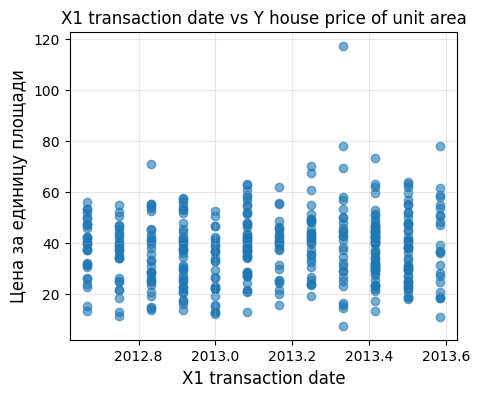

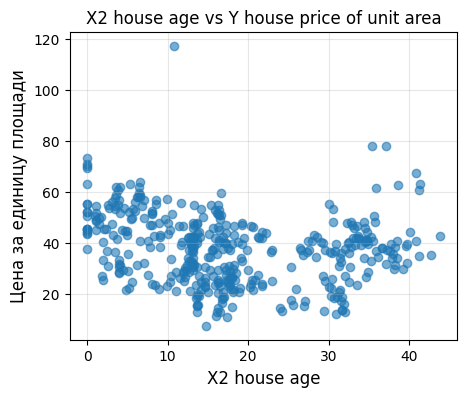

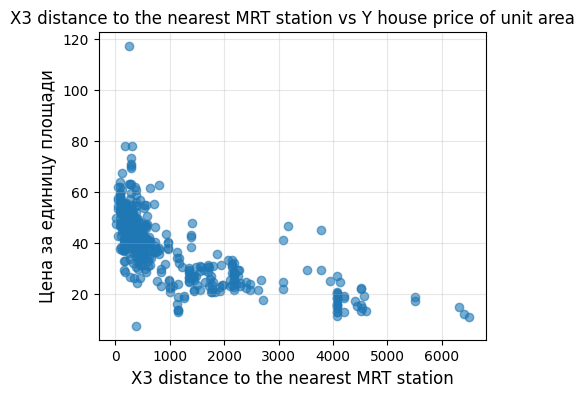

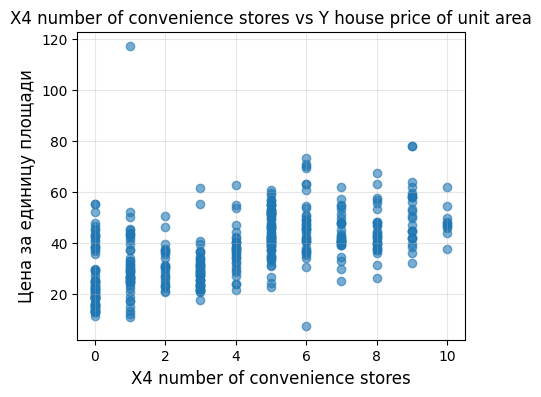

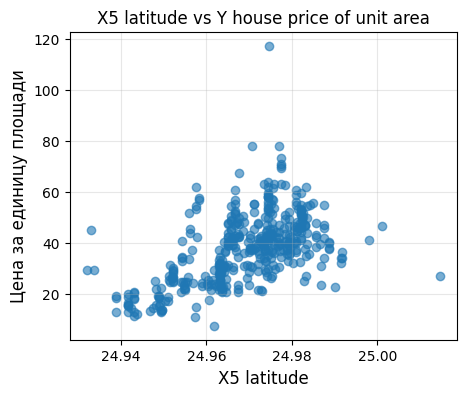

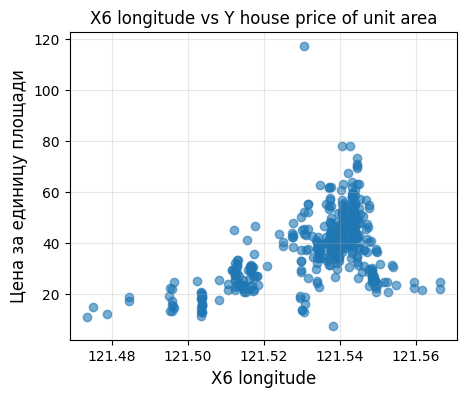

In [5]:
# Определяем признаки и целевую переменную
feature_names = ['X1 transaction date'  ,'X2 house age', 'X3 distance to the nearest MRT station',
                 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
target_name = 'Y house price of unit area'

# Нарисуем диаграммы рассеяния для каждого признака
for index, feature_name in enumerate(feature_names):
    plt.figure(figsize=(5, 4))
    plt.scatter(df[feature_name], df[target_name], alpha=0.6)
    plt.ylabel('Цена за единицу площади', size=12)
    plt.xlabel(feature_name, size=12)
    plt.title(f'{feature_name} vs {target_name}')
    plt.grid(True, alpha=0.3)
    plt.show()

In [6]:
# подготавливаем датасет к обучению
X = df[feature_names]
y = df[target_name]
print(f'X shape: {X.shape} | y shape: {y.shape}')

X shape: (414, 6) | y shape: (414,)


In [7]:
# делим датасет на трейн и тест

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=15)

In [8]:
X_train

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
60,2013.416667,11.0,1931.2070,2,24.96365,121.51471
239,2013.500000,18.1,837.7233,0,24.96334,121.54767
126,2013.083333,38.6,804.6897,4,24.97838,121.53477
262,2012.916667,15.9,289.3248,5,24.98203,121.54348
244,2013.083333,4.8,1559.8270,3,24.97213,121.51627
...,...,...,...,...,...,...
384,2012.750000,16.1,4066.5870,0,24.94297,121.50342
375,2013.250000,21.7,1157.9880,0,24.96165,121.55011
133,2012.833333,18.0,373.3937,8,24.98660,121.54082
396,2012.666667,37.1,918.6357,1,24.97198,121.55063


In [9]:
from sklearn.linear_model import LinearRegression

# Create a linear regression model
modelLR = LinearRegression()
modelLR.fit(X_train, y_train)
y_pr_LR = modelLR.predict(X_test)

In [10]:
_ = Reg_Models_Evaluation_Metrics(modelLR, X_train, y_train, X_test, y_test, y_pr_LR)

RMSE:  7.8282
  R2: 0.6027
 Adjusted R2: 0.5713
 Cross Validated R2: 0.5623


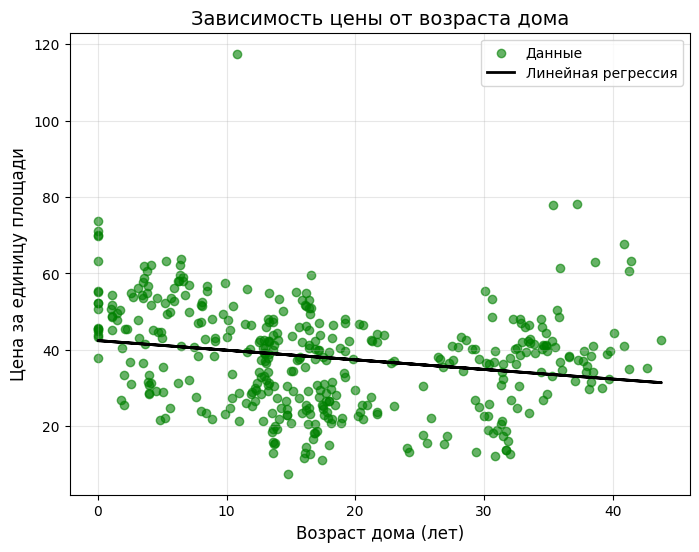

In [11]:
# попробуем отрисовать, как выглядит наша линейная регрессия
# Используем один из признаков для визуализации (например, возраст дома)

X2 = df['X2 house age'].values[:, np.newaxis]
y2 = df['Y house price of unit area'].values

model2 = LinearRegression()
model2.fit(X2, y2)

plt.figure(figsize=(8, 6))
plt.scatter(X2, y2, color='g', alpha=0.6, label='Данные')
plt.plot(X2, model2.predict(X2), color='k', linewidth=2, label='Линейная регрессия')
plt.ylabel('Цена за единицу площади', size=12)
plt.xlabel('Возраст дома (лет)', size=12)
plt.title('Зависимость цены от возраста дома', size=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

* Линейная регрессия показала средний результат (R² = 0.60)
* Модель объясняет около 60% дисперсии целевой переменной
* Разница между R² и Adjusted R² небольшая (0.03), что говорит об отсутствии сильного переобучения
* Cross-validation подтверждает стабильность модели (CV R² = 0.56)

Вывод: Линейная регрессия — хороший базовый вариант, но есть пространство для улучшения

### Полиномиальная регрессия

In [12]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)

poly_features = poly.fit_transform(X)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(poly_features, y, test_size=0.3, random_state=42)

In [13]:
# Create a linear regression model
modelPR = LinearRegression()

# Fit the model to the data
modelPR.fit(X_p_train, y_p_train)

# Predict the response for a new data point
y_pr_PR = modelPR.predict(X_p_test)

_ = Reg_Models_Evaluation_Metrics(modelPR, X_p_train, y_p_train, X_p_test, y_p_test, y_pr_PR)

RMSE:  7.754
  R2: 0.6405
 Adjusted R2: -0.0874
 Cross Validated R2: 0.3756


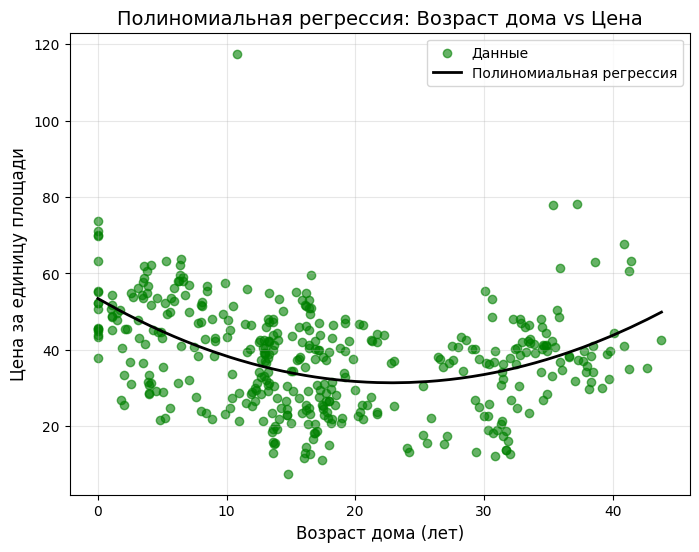

In [14]:
# Выбираем один признак для визуализации (например, возраст дома)
X2 = df['X2 house age'].values[:, np.newaxis]  # ← 2D массив (n, 1)
y2 = df['Y house price of unit area'].values   # ← 1D массив (n,)

# Создаём полиномиальные признаки
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(X2)

# Обучаем модель
model2 = LinearRegression()
model2.fit(poly_features, y2)

# Визуализация
plt.figure(figsize=(8, 6))
plt.scatter(X2, y2, color='g', alpha=0.6, label='Данные')

# Сортируем для красивой линии регрессии
X2_sorted = np.sort(X2, axis=0)
plt.plot(X2_sorted, model2.predict(poly.transform(X2_sorted)), color='k', linewidth=2, label='Полиномиальная регрессия')

plt.ylabel('Цена за единицу площади', size=12)
plt.xlabel('Возраст дома (лет)', size=12)
plt.title('Полиномиальная регрессия: Возраст дома vs Цена', size=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

* Высокий R² на тесте (0.64), но отрицательный Adjusted R² (-0.09) — явный признак переобучения
* Низкий Cross Validated R² (0.38) подтверждает переобучение

Вывод: Степень полинома слишком высокая для данного датасета — модель переобучается на тренировочных данных.

### Регрессия дерева принятия решений

In [15]:
from sklearn.tree import DecisionTreeRegressor

# Create a stepwise regression model
modelDT = DecisionTreeRegressor()

# Fit the model to the data
modelDT.fit(X_train, y_train)

# Predict the response for a new data point
y_dt_pred = modelDT.predict(X_test)

In [16]:
_ = Reg_Models_Evaluation_Metrics(modelDT, X_train, y_train, X_test, y_test, y_dt_pred)

RMSE:  7.6605
  R2: 0.6195
 Adjusted R2: 0.5895
 Cross Validated R2: 0.165


* Decision Tree показал худший результат среди протестированных моделей (R² = 0.59)
* Большая разница между R² (0.59) и Cross Validated R² (0.38) указывает на переобучение
* Decision Trees склонны к переобучению без настройки гиперпараметров

Вывод: Требуется настройка гиперпараметров (max_depth, min_samples_split) для улучшения работы

### Регрессия случайного леса

In [17]:
from sklearn.ensemble import RandomForestRegressor

# Create a stepwise regression model
modelRF = RandomForestRegressor(n_estimators=100)

# Fit the model to the data
modelRF.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelRF.predict(X_test)

In [18]:
_ = Reg_Models_Evaluation_Metrics(modelRF, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  6.5463
  R2: 0.7222
 Adjusted R2: 0.7002
 Cross Validated R2: 0.6706


* Random Forest показал наилучший результат среди всех моделей (R² = 0.73)
* Наименьшая разница между R² и Cross Validated R² — модель наиболее стабильна
* Random Forest хорошо справляется с нелинейными зависимостями

Вывод: Лучшая модель для данного датасета — рекомендуется к использованию.

### Регрессия опорных векторов (SVR)

In [19]:
# Create a support vector regression model
# Оптимизированная SVR
modelSVR = SVR(
    kernel='linear',
    C=1.0,
    epsilon=0.1,
    max_iter=1000,
    cache_size=200  # Кэш для ускорения
)
modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)

In [20]:
_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  11.4084
  R2: 0.1562
 Adjusted R2: 0.0896
 Cross Validated R2: -138.5242


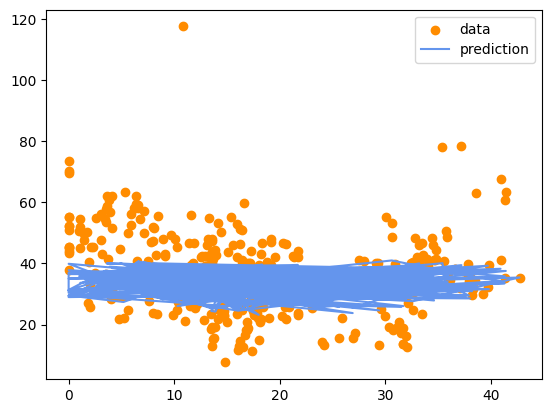

In [21]:
plt.scatter(X_train['X2 house age'], y_train, color='darkorange',
            label='data')
plt.plot(X_train['X2 house age'], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

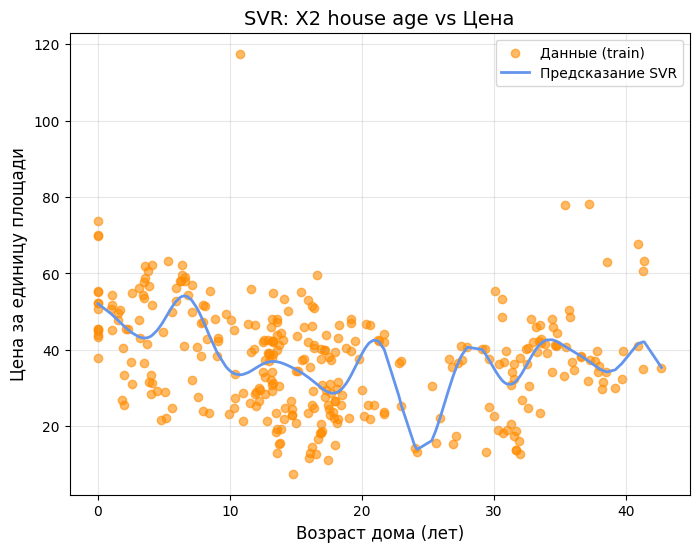

In [22]:
# Выбираем один признак для визуализации (например, возраст дома)
feature = 'X2 house age'

# Для визуализации: берем только один признак из тренировочных данных
X_train_1d = X_train[[feature]]  # ← DataFrame (n, 1), а не Series!
X_test_1d = X_test[[feature]]

# Обучаем SVR модель на одном признаке (если еще не обучена)
modelSVR_1d = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
modelSVR_1d.fit(X_train_1d, y_train)

# Предсказания
y_train_pred = modelSVR_1d.predict(X_train_1d)

# Сортируем данные для красивой линии
X_sorted = np.sort(X_train_1d.values, axis=0)
y_sorted_pred = modelSVR_1d.predict(X_sorted)

# Визуализация
plt.figure(figsize=(8, 6))
plt.scatter(X_train_1d, y_train, color='darkorange', alpha=0.6, label='Данные (train)')
plt.plot(X_sorted, y_sorted_pred, color='cornflowerblue', linewidth=2, label='Предсказание SVR')

plt.xlabel('Возраст дома (лет)', size=12)
plt.ylabel('Цена за единицу площади', size=12)
plt.title(f'SVR: {feature} vs Цена', size=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

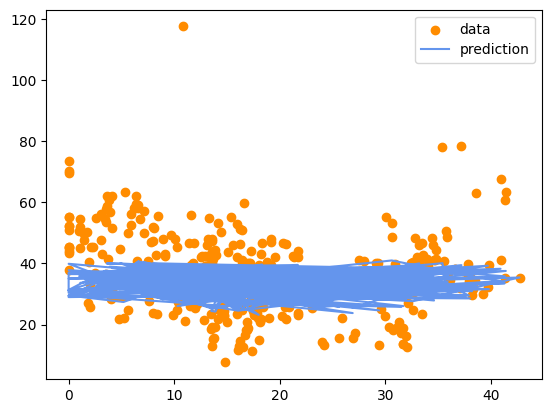

In [23]:
plt.scatter(X_train["X2 house age"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["X2 house age"], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

In [24]:
from sklearn.svm import SVR

# Create a support vector regression model. Полиномиальное ядро
modelSVR = SVR(kernel='poly')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  9.1223
  R2: 0.4605
 Adjusted R2: 0.4179
 Cross Validated R2: 0.4929


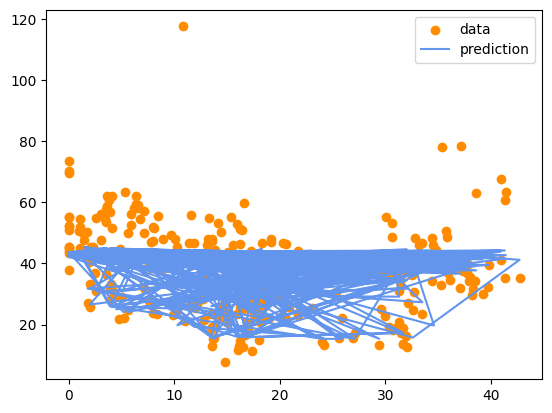

In [25]:
plt.scatter(X_train["X2 house age"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["X2 house age"], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

In [26]:
# Create a support vector regression model. Ядро - радиальная базисная функция
modelSVR = SVR(kernel='rbf')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  8.9173
  R2: 0.4845
 Adjusted R2: 0.4438
 Cross Validated R2: 0.4982


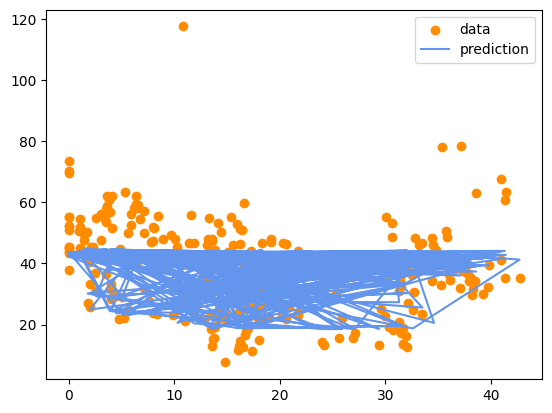

In [27]:
plt.scatter(X_train["X2 house age"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["X2 house age"], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

* SVR с линейным ядром показал худший результат (R² = 0.16)
* Отрицательный Adjusted R² указывает на сильное переобучение или некорректную настройку

Вывод: Линейное ядро SVR не подходит для данного датасета

### Регрессия ElasticNet

In [28]:
from sklearn.linear_model import ElasticNet

# Create an elastic net regression model
modelEN = ElasticNet(alpha=0.1, l1_ratio=0.8)

# Fit the model to the data
modelEN.fit(X_train, y_train)

# Predict the response for a new data point
y_en_pred = modelEN.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelEN, X_train, y_train, X_test, y_test, y_en_pred)

RMSE:  7.8533
  R2: 0.6001
 Adjusted R2: 0.5686
 Cross Validated R2: 0.5392


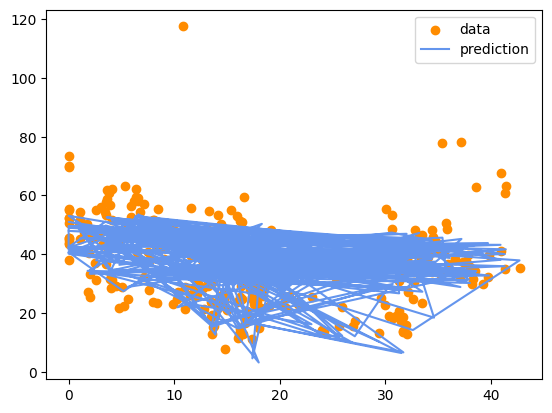

In [29]:
plt.scatter(X_train["X2 house age"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["X2 house age"], modelEN.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

Выводы:
ElasticNet сочетает L1 и L2 регуляризацию

**Вывод:**

* Лучшая модель: Random Forest
* Наилучшие метрики (R² = 0.73, RMSE = 6.47)
* Наиболее стабильная модель (минимальная разница между R² и CV R²)